<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/2%20%2C%203%2C%204%20Makemore/Bigram_self_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
words = open('names.txt', 'r').read().splitlines() #open file in read mode, splitlines converts it into list
print(words[:10])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [3]:
import torch

In [10]:
# Join all words into one long string : Example: ['anna', 'bob'] -> 'annabob'
# set(...) keeps only unique characters
# list(...) converts set back to list
# sorted(...) sorts alphabetically
chars = sorted(list(set(''.join(words))))
print(chars[:3])
# Create String-To-Integer mapping
# enumerate(chars) gives:(0,'a'), (1,'b'), (2,'n'), (3,'o')
# i+1 is used because 0 is reserved for '.'
# Result:{'a':1, 'b':2, 'n':3, 'o':4}
stoi = {s:i+1 for i,s in enumerate(chars)}
print(list(stoi.items())[:3])
# Add special token '.'
# {'.':0, 'a':1, 'b':2, 'n':3, 'o':4}
stoi['.'] = 0

# Create reverse mapping Integer-To-String
# stoi.items() gives:
# ('.',0), ('a',1), ('b',2), ('n',3), ('o',4)
# Reverse key and value:
# {0:'.', 1:'a', 2:'b', 3:'n', 4:'o'}
itos = {i:s for s,i in stoi.items()}
print(list(itos.items())[:3])

['a', 'b', 'c']
[('a', 1), ('b', 2), ('c', 3)]
[(1, 'a'), (2, 'b'), (3, 'c')]


In [11]:
N = torch.zeros((27, 27), dtype=torch.int32) # arrays of zero 26 alphabets plus <E> and <S>=27

In [29]:
for w in words:
    chs= ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2] +=1

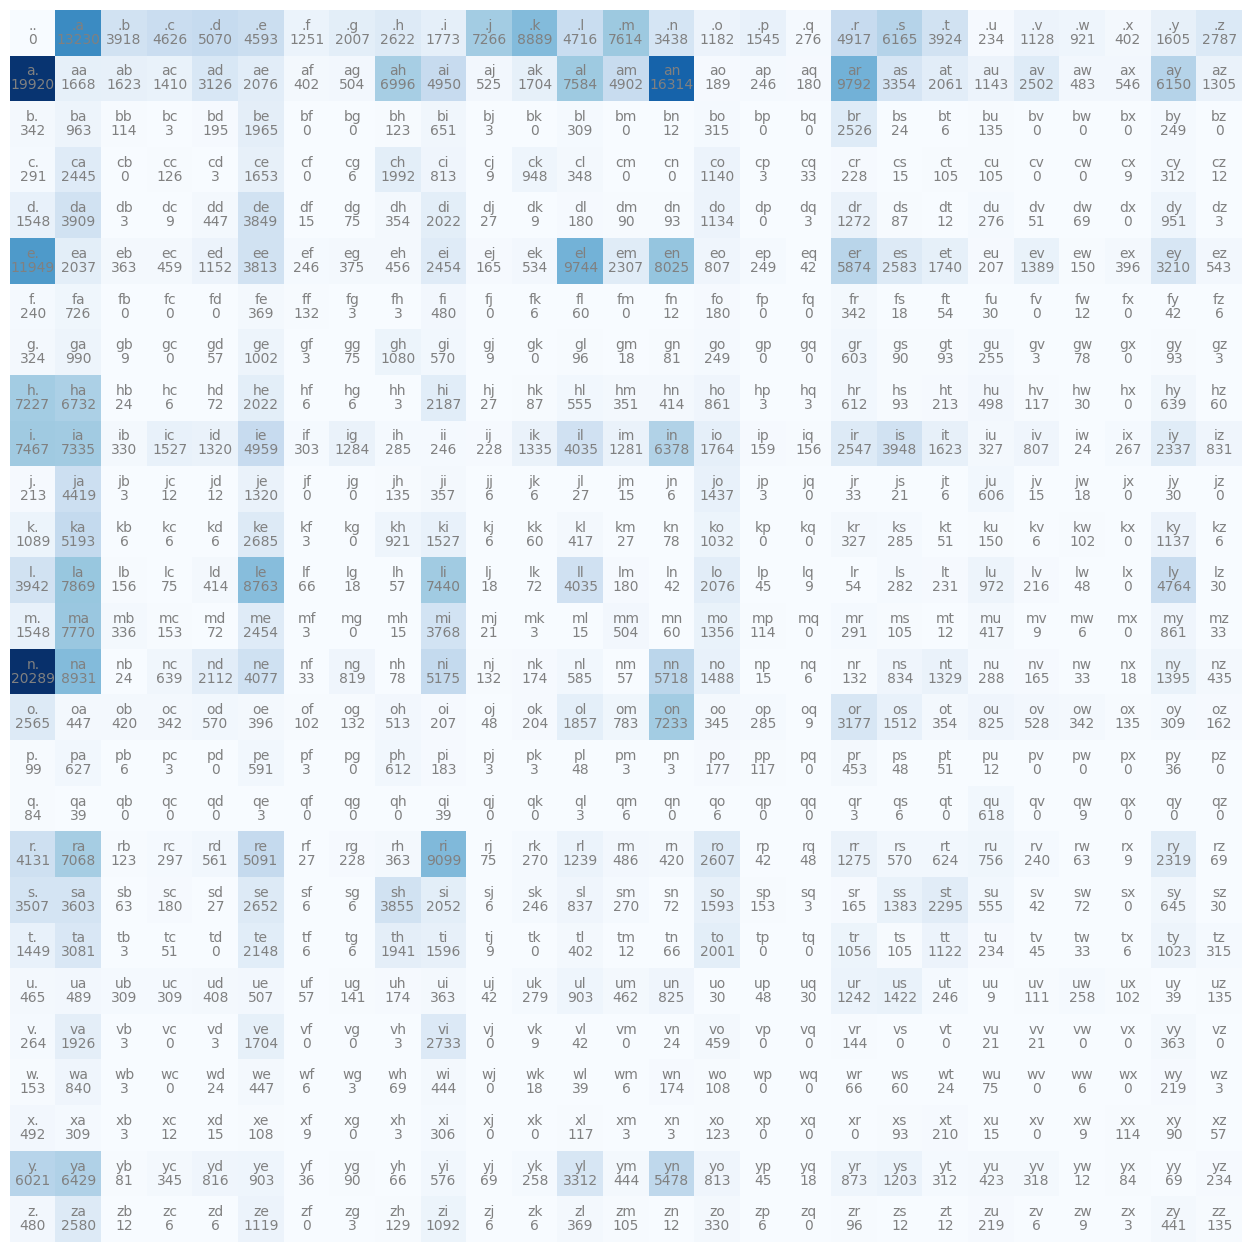

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [70]:
xs,ys=[],[]
for w in words[0:1500]:
    chs= ['.'] + list(w) + ['.']
    for x1,y1 in zip(chs,chs[1:]):
        xs.append(stoi[x1])
        ys.append(stoi[y1])
xs=torch.tensor(xs)
ys=torch.tensor(ys)
num = xs.nelement()
print(xs)
print(ys)
print(num)


tensor([ 0,  5, 13,  ..., 19, 19,  1])
tensor([ 5, 13, 13,  ..., 19,  1,  0])
10566


In [74]:
xs[:10]

tensor([ 0,  5, 13, 13,  1,  0, 15, 12,  9, 22])

In [71]:
import torch.nn.functional as F
g = torch.Generator().manual_seed(42)
W= torch.randn((27,27), generator=g, requires_grad=True)

In [77]:
# gradient descent
for k in range(100):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  #print(probs.shape)
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() # Average negative log-likelihood (cross-entropy) over the batch. + L2 Regularization
  #print(torch.arange(num),ys)
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

2.3005218505859375
2.300511360168457
2.3005003929138184
2.300489664077759
2.300478935241699
2.3004682064056396
2.3004581928253174
2.300448179244995
2.3004379272460938
2.3004276752471924
2.3004181385040283
2.300408363342285
2.300398349761963
2.3003885746002197
2.3003790378570557
2.3003695011138916
2.3003604412078857
2.3003509044647217
2.300341844558716
2.30033278465271
2.300323486328125
2.3003149032592773
2.3003056049346924
2.3002967834472656
2.300288438796997
2.3002796173095703
2.3002712726593018
2.300262928009033
2.3002543449401855
2.300246238708496
2.3002376556396484
2.300229787826538
2.3002214431762695
2.300213575363159
2.300205707550049
2.3001976013183594
2.300189733505249
2.3001821041107178
2.3001744747161865
2.3001668453216553
2.3001596927642822
2.300152063369751
2.3001444339752197
2.3001372814178467
2.3001301288604736
2.3001227378845215
2.3001155853271484
2.3001089096069336
2.3001017570495605
2.3000948429107666
2.3000879287719727
2.3000810146331787
2.300074338912964
2.3000676631

In [73]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(42)

for i in range(5):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

a.
fgeenvt.
s.
ma.
ian.
